In [51]:
#created on 17/04/2026 by James McLoughlin

In [43]:
import cartopy.crs as ccrs
import earthaccess
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import rasterio as rio
from rasterio.enums import Resampling
from rasterio import features
from rasterio.features import shapes
from rasterio.features import sieve
import rasterio.merge
from rasterio.merge import merge
import rioxarray
import shapely
from shapely.geometry import shape
from shapely.geometry import Polygon
from shapely import affinity
import xarray as xr
from xrspatial import hillshade



from cartopy.crs import PlateCarree



#from rasterio.warp import calculate_default_transform, reproject, Resampling
#from rasterio.io import MemoryFile
from rasterio.plot import show




#from rasterio.mask import mask
#from scipy.ndimage import median_filter
#from shapely.geometry import Point

In [44]:
#base = Path("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/two_years")
base = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped")
#base = Path("C:/RS_GIS/EGM722/Assignment/Columbia_Icefield/USGS_data/Unzipped")
river_ref = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/river.shp"

raw_data = base/"raw_data"
NDI_data = base/"Processed_data"/"NDIs"
NDI_data.mkdir(parents=True, exist_ok=True)
mosaics = base/"Processed_data"/"Mosaics"
mosaics.mkdir(parents=True, exist_ok=True)
masks = base/"Processed_data"/"Masks"
masks.mkdir(parents=True, exist_ok=True)
polygons = base/"Processed_data"/"Polygons"
polygons.mkdir(parents=True, exist_ok=True)
earthaccess_data = base / "EarthAccess"
earthaccess_data.mkdir(parents=True, exist_ok=True)
clipped_images = base / "Processed_data" / "Clipped Images" 
clipped_images.mkdir(parents=True, exist_ok=True)

In [45]:
# Dictionaries describing the bands of the landsat satellites and  
satbands = {
    "LT05":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B7":"SWIR2"},
    "LT07":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B6":"TIR", "B7":"SWIR2" },
    "LC08":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"},
    "LC09":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"}
}

index_to_bands = {
    "NDVI": ["RED", "NIR"],
    "NDWI": ["GREEN", "NIR"],
    "NDSI": ["GREEN", "SWIR1"]
}

In [46]:
def mosaicking (yr, NDI):
    for yr in df["year"].unique():
        for colr in index_to_bands[NDI]:
            file_list = df[(df["year"] == yr) & (df["colour"] == colr)]["path"].tolist()
            mosaic_out = mosaics / f"{yr}_{colr}_mosaic.tif" 
            rio.merge.merge(file_list, dst_path = mosaic_out)

In [24]:
# NDI = 'NDVI'
# for yr in df["year"].unique():
#     for colr in index_to_bands[NDI]:
#         file_list = df[(df["year"] == yr) & (df["colour"] == colr)]["path"].tolist()
#         mosaic_out = mosaic_data / f"{yr}_{colr}_mosaic.tif" 
#         rio.merge.merge(file_list, dst_path = mosaic_out)

In [52]:
### Clipping rasters
def clipping(yr, NDI, ref_poly):
    for colr in index_to_bands[NDI]:
        landsat_scene = mosaics / f"{yr}_{colr}_mosaic.tif"
        # landsat_scene = df[(df["colour"] == colr) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
        rds = rioxarray.open_rasterio(landsat_scene)
        gdf = gpd.read_file(ref_poly).to_crs(rds.rio.crs)
        clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
        clipped_out = clipped_images / f"{yr}_{colr}_clipped.tif"
        clipped.rio.to_raster(clipped_out)

In [54]:
#Function to calculate NDI
def NDI_calculation(yr, NDI):
    colr1 = index_to_bands[NDI][0]
    colr2 = index_to_bands[NDI][1]
    path1 = clipped_images / f"{yr}_{pr}_{colr1}_clipped.tif"
    path2 = clipped_images / f"{yr}_{pr}_{colr2}_clipped.tif"
#    path1 = df[(df["colour"] == colr1) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#    path2 = df[(df["colour"] == colr2) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
    
    with rio.open(path1) as src1, rio.open(path2) as src2:
        tile1 = src1.read(1).astype("float32")
        tile2 = src2.read(1).astype("float32")
        with np.errstate(invalid='ignore'):
            ndi_img = (tile1 - tile2) / (tile1+tile2)
        ndi_img[np.isnan(ndi_img)] = -9999 
        ndi_out = NDI_data / f"{yr}_{pathrow}_{NDI}.tif"
        out_meta = src1.meta.copy()
        out_meta.update(dtype = "float32", nodata = -9999)

    with rio.open(ndi_out, "w", **out_meta) as dst:
        dst.write(ndi_img,1)

In [5]:
# 
#Function to calculate NDI
# def NDI_calculation(yr, pathrow, NDI, clipped):
#     colr1 = index_to_bands[NDI][0]
#     colr2 = index_to_bands[NDI][1]
#     if clipped == 0:
#         path1 = df[(df["colour"] == colr1) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#         path2 = df[(df["colour"] == colr2) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#     elif clipped == 1:
#         path1 = clipped_images / f"{yr}_{pr}_{colr1}_clipped.tif"
#         path2 = clipped_images / f"{yr}_{pr}_{colr2}_clipped.tif"
    
#     with rio.open(path1) as src1, rio.open(path2) as src2:
#         tile1 = src1.read(1).astype("float32")
#         tile2 = src2.read(1).astype("float32")
#         with np.errstate(invalid='ignore'):
#             ndi_img = (tile1 - tile2) / (tile1+tile2)
#         ndi_img[np.isnan(ndi_img)] = -9999 
##         if clipped == 0:
##             ndi_out = NDI_data / f"{yr}_{pathrow}_{NDI}.tif"
##         elif clipped == 1:
#             ndi_out = NDI_data / f"{yr}_{pathrow}_{NDI}.tif"
#         out_meta = src1.meta.copy()
#         out_meta.update(dtype = "float32", nodata = -9999)

#     with rio.open(ndi_out, "w", **out_meta) as dst:
#         dst.write(ndi_img,1)

In [35]:
### function for making mask, binarising it, and converting to polygons
def mask_from_raster(year, pathrow, NDI):#, river_ref_path):
    poly_list = []
    file = NDI_data/f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        non_binary = src.read(1)
        mask = np.where(non_binary > -0.1 , 255 ,0).astype("uint8")
        cleaned_mask = sieve(mask,50)
        out_meta = src.meta.copy()
        out_meta.update(dtype = "uint8", nodata = 0)
        mask_out = masks / f"{year}_{pathrow}_{NDI}.tif"
        
        with rio.open(mask_out, "w", **out_meta) as dst:
            dst.write(cleaned_mask,1)

    file = mask_data / f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        tile = src.read(1).astype("int16")
        out_meta = src.meta.copy()
        mask_shapes = features.shapes(
            tile,
            mask = tile > 0,
            transform = out_meta['transform']
        )
    # The corrected list comprehension
    polygons = [
    {'geometry':shape(s),'properties':{'id': i}}
     for i, (s,v) in enumerate(mask_shapes)
    ]
              
    gdf = gpd.GeoDataFrame.from_features(polygons, crs=out_meta['crs'])
    return gdf

In [36]:
#function for isolationg and joing the river polygons
def merging_polygons(poly_gdf, ref_poly):
    combined_gdf = pd.concat(poly_gdf)
    
    #Apply buffer to bridge gaps between tiles
    combined_gdf['geometry'] = combined_gdf.geometry.buffer(100) 
    
    #Weld small localised pieces together
    merged = combined_gdf.union_all()
    
    # Searate main bodies into distinct polygons
    main_polygons = gpd.GeoSeries([merged], crs="EPSG:26912").explode(index_parts=False)
    main_polygons_gdf = gpd.GeoDataFrame(geometry=main_polygons)
   
    # Keep only polygons that touch river reference
    # ensures small 'ilsnad' polyons in the river path are not omitted.
    ref_geom = gpd.read_file(ref_poly).to_crs("EPSG:26912").union_all()
    referenced_poly = main_polygons_gdf[main_polygons_gdf.intersects(ref_geom)]
   
    # 5. Shrink it back (undo the buffer) to get original river width
    referenced_poly['geometry'] = referenced_poly.geometry.buffer(-100)
    buffered_poly = referenced_poly.copy()
    buffered_poly['geometry'] = buffered_poly.geometry.buffer(5000)

    poly_out = polygon_data / "Grand_Canyon_River.gpkg"
    buff_out = polygon_data / "Grand_Canyon_River_Buffer_5000.gpkg"
    referenced_poly.to_file(poly_out, driver="GPKG")
    buffered_poly.to_file(buff_out, driver="GPKG")

In [ ]:
#----------------- useful code that needs to become either a function or put in the main pipeline

In [49]:
#Building the dataframe of raw data files
records = []
for folder in raw_data.iterdir():
    if folder.is_dir():
        for file in folder.glob("*_SR_B*.TIF"):
            parts = file.name.split("_")
            sat = parts[0]
            band = parts[-1].replace(".TIF", "")
            records.append({
                "folder": folder.name,
                "file": file.name,
                "path": file,
                "year": parts[3][:4],
                "satellite": sat,
                "path_row": parts[2],
                "band": band,
                "colour": satbands[sat][band]
            })
df = pd.DataFrame(records)

In [ ]:
#---------------------------------------------------------------------------

In [39]:
# mosaic_file = mosaic_data / "2020_RED_mosaic.tif"
# with rio.open(mosaic_file) as dataset:
#     fig, ax = plt.subplots(figsize=(10, 10))
#     show(dataset, ax=ax)   # <-- key change
#     plt.show()

In [50]:
# main pipleine
all_polygons = []
park_poly_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
park_poly = gpd.read_file(park_poly_file).to_crs(epsg = 26912).union_all()
park_ploy_buffered = park_poly.buffer(1000)
park_buff_gdf = gpd.GeoDataFrame(geometry=[park_ploy_buffered],crs=('EPSG:26912'))
park_ref_out = polygons / "buffered_park_polygon.gpkg"
park_buff_gdf.to_file(park_ref_out, driver ="GPKG")






In [55]:
# main pipleine
for yr in df["year"].unique():
    for pr in df["path_row"].unique():
        mosaicking (yr, "NDVI")
#        clipping(yr,pr,"NDWI", park_ref_out)
        clipping(yr,"NDVI", park_ref_out)
#        NDI_calculation(yr, pr, 'NDWI')
        NDI_calculation(yr, 'NDVI')
#        mask_segment = mask_from_raster(yr, pr, 'NDWI')
#        all_polygons.append(mask_segment.to_crs("EPSG:26912"))

#merging_polygons(all_polygons, river_ref)

RasterioIOError: C:\RS_GIS\EGM722\Assignment\Grand_Canyon\USGS_data\Unzipped\Processed_data\Clipped Images\2020_037035_RED_clipped.tif: No such file or directory

In [13]:
# creting bounding box for earth access search
#boundary_file = polygon_data / "Grand_Canyon_River_Master.gpkg"
boundary_file = polygon_data / "buffered_park_polygon.gpkg"
outline = gpd.read_file(boundary_file).to_crs(epsg = 4326).union_all()
search_area = outline.minimum_rotated_rectangle
search_area = shapely.geometry.polygon.orient(search_area, sign=1)
#getting dem data from earthaccess
earthaccess.login(strategy='netrc')
results = earthaccess.search_data(
    short_name = 'ASTGTM',
    polygon = search_area.exterior.coords
)
download_file = earthaccess.download(results, earthaccess_data)

C:\Users\jj_mc\anaconda3\envs\EGM722-Assessment\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
C:\Users\jj_mc\anaconda3\envs\EGM722-Assessment\Lib\site-packages\earthaccess\store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
# 1. Load the DEM and Reclassify into integer 'zones'
with rasterio.open('dem.tif') as src:
    dem = src.read(1)
    # Reclassify: e.g., 0-500m becomes 1, 500-1000m becomes 2, etc.
    # // is floor division; this creates discrete elevation 'bands'
    zones = (dem // 500).astype(np.int32)
    transform = src.transform
    crs = src.crs

# 2. Vectorize: Turn those zones into Polygons
# This finds contiguous areas of the same integer 'zone'
results = (
    {'properties': {'elev_zone': v}, 'geometry': s}
    for i, (s, v) in enumerate(features.shapes(zones, transform=transform))
    if v != src.nodata  # Ignore NoData areas
)

# 3. Create a GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(list(results), crs=crs)

In [14]:
# mosaics the DEMs
dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
dem_merged_path = earthaccess_data / "DEM_merged.TIF"
rio.merge.merge(dem_files, dst_path=dem_merged_path, dtype = 'float32')
with rio.open(dem_merged_path) as dataset:
    dem = dataset.read(1)
    crs = dataset.crs
    xmin, ymin, xmax, ymax = dataset.bounds

In [16]:
### Clipping DEM
boundary_file = polygon_data / "buffered_park_polygon.gpkg"
dem_path = earthaccess_data / "DEM_merged.TIF"
rds = rioxarray.open_rasterio(dem_path)
gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs)
#nodata_val = -9999 
#clipped.rio.write_nodata(nodata_val, inplace=True))
clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
clipped_out = clipped_images / "clipped DEM.tif"
clipped.rio.to_raster(clipped_out)

In [39]:
with rio.open(clipped_out) as src:
    dem = src.read(1)
    meta = src.meta.copy()
    #dem_min = np.nanmin(dem)
    #dem_max = np.nanmax(dem)

#print(f"Max: {dem_max}, Min: {dem_min}")
bins = [500, 1000, 1500, 2000, 2500, 3000]

grouped_dem = np.digitize(dem,bins)
print(type(grouped_dem))
#meta.update(dtype=rasterio.int32)
#dem_clss_path = earthaccess_data / "DEM_classified.tif"
#with rio.open(dem_clss_path, "w", **meta) as dst:
#    dst.write(grouped_dem.astype(rasterio.int32),1)
    

<class 'numpy.ndarray'>


In [40]:
grouped_dem

array([[6, 6, 6, ..., 6, 6, 6],
       [6, 6, 6, ..., 6, 6, 6],
       [6, 6, 6, ..., 6, 6, 6],
       ...,
       [6, 6, 6, ..., 6, 6, 6],
       [6, 6, 6, ..., 6, 6, 6],
       [6, 6, 6, ..., 6, 6, 6]], shape=(4405, 8557))

TypeError: 'DataArray' object is not callable

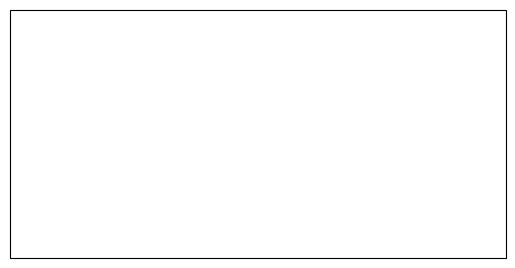

In [18]:
# Plots the mosaicked DEM layer
#data_crs=ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(clipped(1), cmap='gray', transform=ccrs.PlateCarree(), extent=[xmin, xmax, ymin, ymax]) # display band 0 as a grayscale image, stretched between 0 and 400
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())
plt.show()

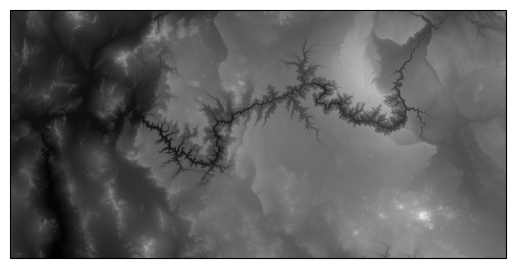

In [61]:
# Plots the mosaicked DEM layer
#data_crs=ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(dem, cmap='gray', transform=ccrs.PlateCarree(), extent=[xmin, xmax, ymin, ymax]) # display band 0 as a grayscale image, stretched between 0 and 400
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())
plt.show()

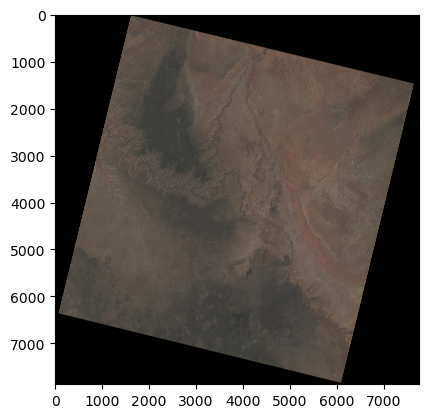

In [90]:
# creating composite images
def normalize(band):
    band_max, band_min = band.max(), band.min()
    norm = ((band - band_min)/(band_max - band_min))
    return norm
    
yr = '2020'
pr = '037035'
#file paths
blue_file = df[(df["colour"] == "BLUE") & (df["year"] == yr) & (df["path_row"] == pr)]["path"].iloc[0]
green_file = df[(df["colour"] == "GREEN") & (df["year"] == yr) & (df["path_row"] == pr)]["path"].iloc[0]
red_file = df[(df["colour"] == "RED") & (df["year"] == yr) & (df["path_row"] == pr)]["path"].iloc[0]

with rio.open(blue_file) as b_src, rio.open(green_file) as g_src, rio.open(red_file) as r_src:
    blue = b_src.read(1)
    green = g_src.read(1)
    red = r_src.read(1)
    out_meta = r_src.meta.copy()
    nblue = normalize(blue)
    ngreen = normalize(green)
    nred = normalize(red)

rgb_composite = np.dstack((nred, ngreen, nblue))
plt.imshow(RGB_composite)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

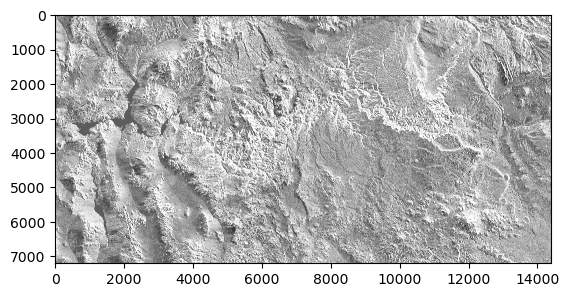

In [110]:
dem_path = earthaccess_data / "DEM_merged.TIF"
with rio.open(dem_path) as src:
    dem = src.read(1)
elevation_da = xr.DataArray(dem, dims=['y', 'x'])
illuminated = hillshade(elevation_da, azimuth=315, angle_altitude=45)
plt.imshow(illuminated, cmap='Greys')
plt.show

In [2]:
x = [1, 2, 3, 4]
y = ['a', 'b', 'c', 'd']
z = ['i', 'ii', 'iii', 'iv']

print(list(zip(x, y, z)))

[(1, 'a', 'i'), (2, 'b', 'ii'), (3, 'c', 'iii'), (4, 'd', 'iv')]


ValueError: dictionary update sequence element #0 has length 3; 2 is required

In [99]:
# not sure about this DM clipping
# import numpy as np

# # 1. Open with masked=False to keep original data types if preferred
# rds = rioxarray.open_rasterio(dem_path, masked=False)

# gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs)

# # 2. Clip and explicitly set the fill value for areas outside the polygon
# clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True, all_touched=True)

# # 3. Write a specific NoData value (e.g., -9999 or 0) into metadata
# # Ensure the chosen value doesn't exist in your actual DEM data
# nodata_val = -9999 
# clipped.rio.write_nodata(nodata_val, inplace=True)

# # 4. Fill actual empty areas with that value before saving
# clipped = clipped.fillna(nodata_val)

# clipped_out = clipped_images / "clipped_DEM.tif"
# clipped.rio.to_raster(clipped_out)

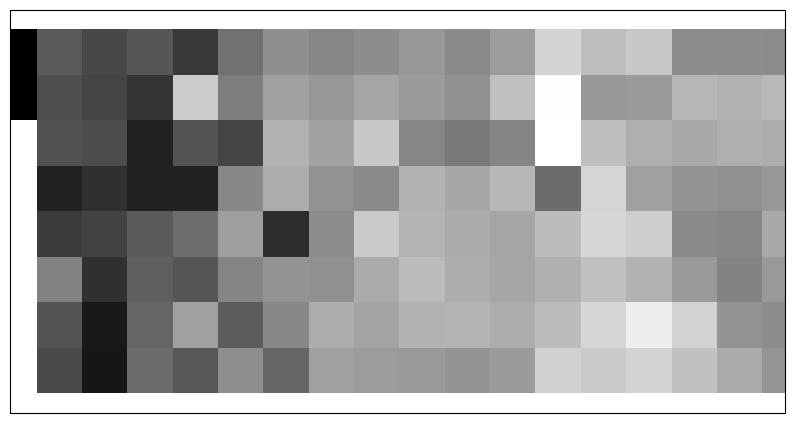

In [42]:
### mosaics the dem's, but uses a virtual raster to spped the process, converts dem to 32612 for comparison against raster
# 1. Define your paths 
dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
vrt_path = earthaccess_data / "combined.vrt"
dem_merged_4326 = earthaccess_data / "DEM_merged_4326.tif"
dem_final_26912 = earthaccess_data / "DEM_final_26912.tif"

# 2. Create the file list string
files_to_merge = " ".join([f'"{str(f)}"' for f in dem_files])

# 3. Run the fast commands
os.system(f"gdalbuildvrt {vrt_path.as_posix()} {files_to_merge}")
os.system(f"gdal_translate -ot Float32 {vrt_path.as_posix()} {dem_merged_4326.as_posix()}")

# Projecting to Meters (EPSG:32612) for analysis
os.system(f"gdalwarp -t_srs EPSG:26912 -r bilinear -ot Float32 {dem_merged_4326.as_posix()} {dem_final_26912.as_posix()}")

# 4. Open the PROJECTED result for plotting/analysis
with rio.open(dem_final_26912) as dataset:
    # Use the downsampling trick here if the plot is still slow!
    dem = dataset.read(1) 
    crs = dataset.crs
    # Note: These bounds will now be in METERS, not degrees
    xmin, ymin, xmax, ymax = dataset.bounds

data_crs = ccrs.UTM(zone=12) 
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(dem, cmap='gray', transform=data_crs, extent=[xmin, xmax, ymin, ymax])
ax.set_extent([xmin, xmax, ymin, ymax], crs=data_crs)
plt.show()

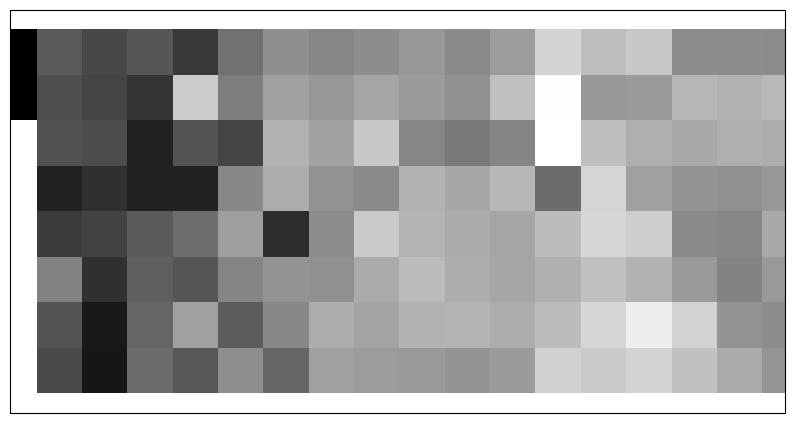

In [38]:
#plotting the dem's, but downselcting the data to speed the proces. dONSELCTION IS FOR VISUAL PURPOSES ONLY.
dem_path = earthaccess_data / "DEM_final_26912.tif"
with rio.open(dem_path) as dataset:
    downsample_factor = 1  # Increase this if it still crashes (e.g., to 8 or 10)
    dem = dataset.read(
        1,
        out_shape=(
            int(dataset.height / downsample_factor),
            int(dataset.width / downsample_factor)
        ),
        resampling=Resampling.bilinear
    )
    src_crs = dataset.crs
    xmin, ymin, xmax, ymax = dataset.bounds

data_crs = ccrs.UTM(zone=12) 
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(dem, cmap='gray', transform=data_crs, extent=[xmin, xmax, ymin, ymax])
ax.set_extent([xmin, xmax, ymin, ymax], crs=data_crs)
plt.show()

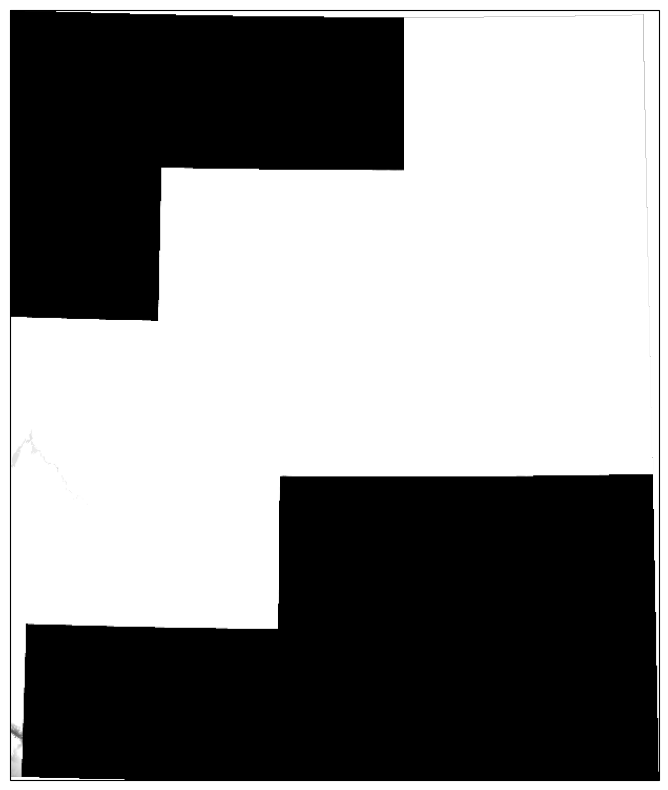

In [17]:
from rasterio.merge import merge
from rasterio.enums import Resampling
# 1. Merge directly to float32 to save ~1.7GB of RAM immediately
# Using 'dtype' here prevents the initial 3.38GB float64 allocation
mosaic, out_trans = rio.merge.merge(dem_files, dtype='float32')

# 2. Update metadata to reflect the 32-bit change
with rio.open(dem_files[0]) as src:
    out_meta = src.profile.copy()

out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "dtype": 'float32'
})

# 3. Write the merged file to disk
dem_merged_path = earthaccess_data / "DEM_merged.tif"
with rio.open(dem_merged_path, "w", **out_meta) as dest:
    dest.write(mosaic)

# 4. Use "Decimation" to read a smaller version for plotting
# You cannot plot 450 million pixels on a 16GB machine; this reads every 4th pixel.
with rio.open(dem_merged_path) as dataset:
    downsample_factor = 4  # Increase this if it still crashes (e.g., to 8 or 10)
    dem = dataset.read(
        1,
        out_shape=(
            int(dataset.height / downsample_factor),
            int(dataset.width / downsample_factor)
        ),
        resampling=Resampling.bilinear
    )
    xmin, ymin, xmax, ymax = dataset.bounds

# 5. Plot the downsampled data
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection=ccrs.epsg(26912)))
ax.imshow(dem, cmap='grey', 
          transform=ccrs.PlateCarree(), 
          extent=[xmin, xmax, ymin, ymax])
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())
plt.show()


In [73]:
# ### mosaics the dem's, but uses a virtual raster to spped the process
# # 1. Define your paths (ensure you add .tif for the output)
# dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
# vrt_path = earthaccess_data / "combined.vrt"
# dem_merged_path = earthaccess_data / "DEM_merged_18.tif"

# # 2. Create the file list string with quotes (handles spaces in folder names)
# files_to_merge = " ".join([f'"{str(f)}"' for f in dem_files])

# # 3. Run the fast commands
# os.system(f"gdalbuildvrt {vrt_path} {files_to_merge}")
# os.system(f"gdal_translate -ot Float32 {vrt_path} {dem_merged_path}")
# os.system(f"gdalwarp -t_srs EPSG:32612 -r bilinear -ot Float32 DEM_merged_36.tif DEM_final_32612.tif")

# # 4. Open and read the final result
# with rio.open(dem_merged_path) as dataset:
#     dem = dataset.read(1)  # Read as a 2D array for plotting
#     crs = dataset.crs
#     xmin, ymin, xmax, ymax = dataset.bounds

In [ ]:
# #mosiacing 6 test dems
# dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
# dem_merged_path = earthaccess_data / "DEM_merged_6"
# rio.merge.merge(dem_files, dst_path=dem_merged_path, dtype = 'float32')
# with rio.open(dem_merged_path) as dataset:
#     dem = dataset.read(1)
#     crs = dataset.crs
#     xmin, ymin, xmax, ymax = dataset.bounds

In [133]:
#### COPY
# creating the inital buffer for the study
# park_poly_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
# park_poly = gpd.read_file(park_poly_file).to_crs(epsg = 26912).union_all()
# park_ploy_buffered = park_poly.buffer(1000)
# park_buff_gdf = gpd.GeoDataFrame(geometry=[park_ploy_buffered],crs=('EPSG:26912'))
# park_ref_out = polygon_data / "buffered_park_polygon.gpkg"
# park_buff_gdf.to_file(park_ref_out, driver ="GPKG")

In [128]:
### Backup clipping images, not a function
#def clipping(input_polygon, reference_polygon):
# poly_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped/Processed_data/Polygons/Grand_Canyon_River.gpkg"
# ref_file ="C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
# in_poly = gpd.read_file(poly_file).to_crs(epsg = 26912).union_all()
# ref_poly = gpd.read_file(ref_file).to_crs(epsg = 26912).union_all()
# #buff_ref = affinity.scale(ref_poly, xfact=1.0, yfact=1.3, origin='center')
# buff_ref = ref_poly.buffer(1000)
# river_clip = in_poly.intersection(buff_ref)
# main_gdf = gpd.GeoDataFrame(geometry=[river_clip],crs=('EPSG:26912'))
# buff_gdf = gpd.GeoDataFrame(geometry=[buff_ref],crs=('EPSG:26912'))
# clip_out = polygon_data / "river_clip.gpkg"
# buff_ref_out = polygon_data / "buffered_park_y_3.gpkg"
# main_gdf.to_file(clip_out, driver ="GPKG")
# buff_gdf.to_file(buff_ref_out, driver ="GPKG")

In [67]:
#### this scell works, though could also be reprojecting
file_list = [f for f in NDI_out.iterdir() if f.is_file()]
with rio.open(file_list[0]) as ref:
    target_crs = ref.crs
srcs = []
for f in file_list:
    src = rio.open(f)
    if src.crs != target_crs:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        meta = src.meta.copy()
        meta.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
    
        data = np.empty((src.count, height, width), dtype=src.dtypes[0])
    
        for i in range(1, src.count + 1):
            reproject(
                source=rio.band(src, i),
                destination=data[i-1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )
        memfile = MemoryFile()
        dataset = memfile.open(**meta)
        dataset.write(data)
        srcs.append(dataset)
    else:
        srcs.append(src)
mosaic, transform = merge(srcs)

out_path = mosaic_out / "NDWI-TEST.tif"
meta = srcs[0].meta.copy()
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

with rio.open(out_path, "w", **meta) as dst:
    dst.write(mosaic)

print(f"Saved: {out_path}")

Saved: C:\RS_GIS\EGM722\Assignment\Grand_Canyon\USGS_data\Unzipped\Processed_data\Mosaic\NDWI-TEST.tif


In [14]:
def reproject_raster(src, dst_crs):
    transform, width, height = rio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    data = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rio.band(src, i),
            destination=data[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    return data, kwargs

In [58]:
def reproject_raster(src, dst_crs):
    transform, width, height = rio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    data = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rio.band(src, i),
            destination=data[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    return data, kwargs
    
mosaic_out = base/"Processed_data"/"Mosiac"
mosaic_out.mkdir(parents=True, exist_ok=True)

 
for yr in df["year"].unique():
    for colr in NDI:
        file_list = df[
            (df["year"] == yr) &
            (df["colour"] == colr)
            ]["path"].tolist()
        srcs = []
        for f in file_list:
            src = rio.open(f)
            if src.crs != target_crs:
                data, meta = reproject_raster(src, target_crs)
                srcs.append((data, meta))
            else:
                srcs.append((src.read(), src.meta))
        datasets = []
        for data, meta in srcs:
            memfile = MemoryFile()
            dataset = memfile.open(**meta)
            dataset.write(data)
            datasets.append(dataset)
        mosaic, transform = merge(datasets)
        print(mosaic.shape)
#            arrays.append(data)
#            srcs.append(src)
#            file_list = df[
#                (df["year"] == yr) &
#                (df["colour"] == colr)
#                ]["path"].tolist()
#            scrs = [rio.open(f) for f in file_list]
#            mosaic, transform = merge(srcs)
#            out_path = mosaic_out / f"{yr}_{colr}_mosaic.tif")
#            rio.merge.merge(file_list, dst_path = out_path)


(1, 11746, 19958)
(1, 11746, 19958)
